In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def tomar_dataframes(ruta_carpeta, usecols=None, n_expected=5):
    """Lee todos los CSV en la carpeta y devuelve una tupla de DataFrames.
    Si `usecols` se pasa, `pd.read_csv` leerá solo esas columnas para acelerar la carga."""
    ruta_carpeta = Path(ruta_carpeta)
    archivos = sorted(ruta_carpeta.glob("*.csv"))

    if len(archivos) != n_expected:
        raise ValueError(f"Se esperaban {n_expected} archivos CSV en {ruta_carpeta}, pero se encontraron {len(archivos)}")

    dfs = []
    for archivo in archivos:
        try:
            if usecols is not None:
                df = pd.read_csv(archivo, usecols=usecols)
            else:
                df = pd.read_csv(archivo)
        except Exception:
            # fallback al leer todo si fallan los usecols
            df = pd.read_csv(archivo)
        dfs.append(df)

    return tuple(dfs)


# Rutas (ajusta si es necesario)
ruta_gazebo = "/home/javier/Desktop/Latex_Rendimiento/TFM_Rendimiento/Rendimiento/Gazebo_2/CSV"
ruta_o3de = "/home/javier/Desktop/Latex_Rendimiento/TFM_Rendimiento/Rendimiento/O3DE/CSV"


# Columnas utilizadas para el análisis

Estas son las columnas que vamos a usar para comparar el rendimiento entre simuladores. Las he separado entre métricas de sistema y métricas de proceso, porque no todas miden lo mismo.

## Métricas de sistema

- `snapshot_index`: número de la captura dentro de cada ejecución. Sirve para ordenar las muestras.
- `timestamp`: hora exacta en la que se tomó la muestra. Útil para ver la evolución temporal.
- `source_file`: archivo original del que sale la muestra. Permite identificar el experimento o simulación.
- `load1`: carga media del sistema en el último minuto. Es una señal rápida de saturación reciente.
- `load5`: carga media de los últimos 5 minutos. Suaviza más el comportamiento.
- `load15`: carga media de los últimos 15 minutos. Sirve para ver una tendencia más estable.
- `cpu_id`: porcentaje de CPU inactiva. Cuanto más bajo, más ocupada está la máquina.
- `mem_used_mib`: memoria usada en MiB. Da una medida absoluta del consumo de memoria.

## Métricas de proceso

- `cpu_pct`: porcentaje de CPU usado por el proceso. Es una de las mejores para comparar qué simulador carga más.
- `mem_pct`: porcentaje de memoria usado por el proceso. Muy útil para comparar consumo de RAM.
- `pid`: identificador del proceso. Sirve para distinguir procesos concretos.
- `user`: usuario que ejecuta el proceso. Puede ayudar a separar procesos del sistema y de tu sesión.
- `command`: nombre o comando del proceso. Es clave para saber qué aplicación está consumiendo recursos.

En este análisis, las métricas más importantes para comparar simuladores son `cpu_pct`, `mem_pct`, `load1` y `cpu_id`.


Top commands combinados: ['Editor', 'ruby', 'rviz2']
cpu_ylim= (0, np.float64(33.62625)) mem_ylim= (0, np.float64(10.605))

=== Gazebo ===
Top commands for G: ['Editor', 'ruby', 'rviz2']


,media,moda,mediana,minimo,maximo,rango
muestra,,,,,,
G1-G5,12.020993,0.0,12.0125,0.0,31.6125,0.0000 - 31.6125



=== O3DE ===
Top commands for O: ['Editor', 'ruby', 'rviz2']


,media,moda,mediana,minimo,maximo,rango
muestra,,,,,,
O1-O5,15.704127,0.0,5.875,0.0,32.025,0.0000 - 32.0250


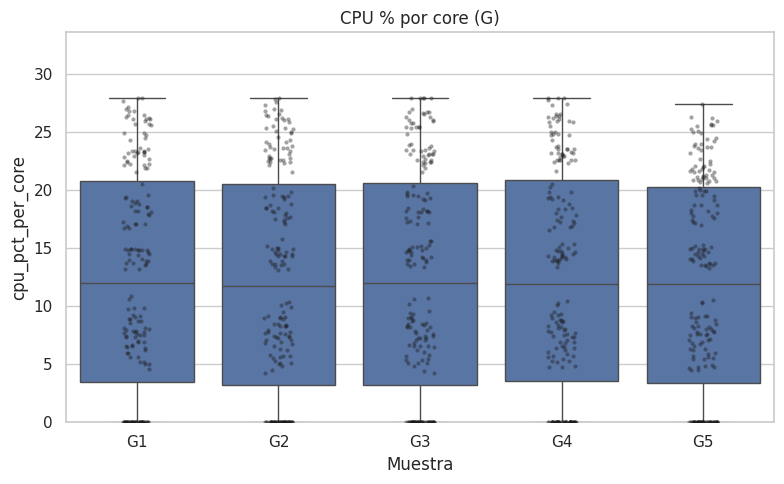

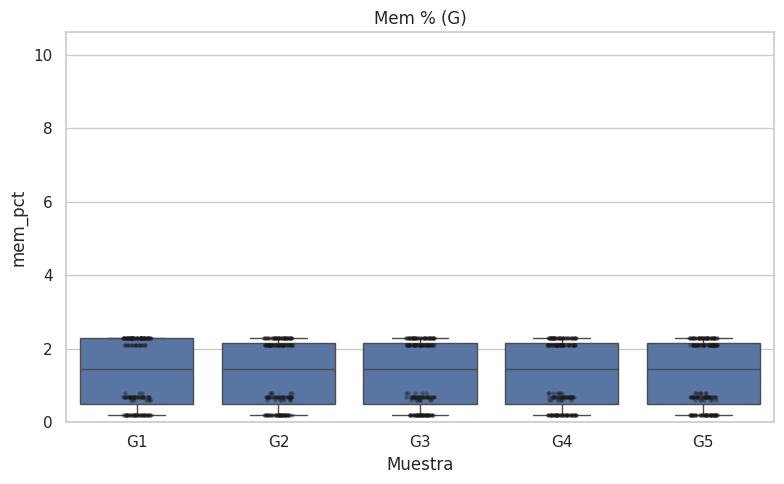

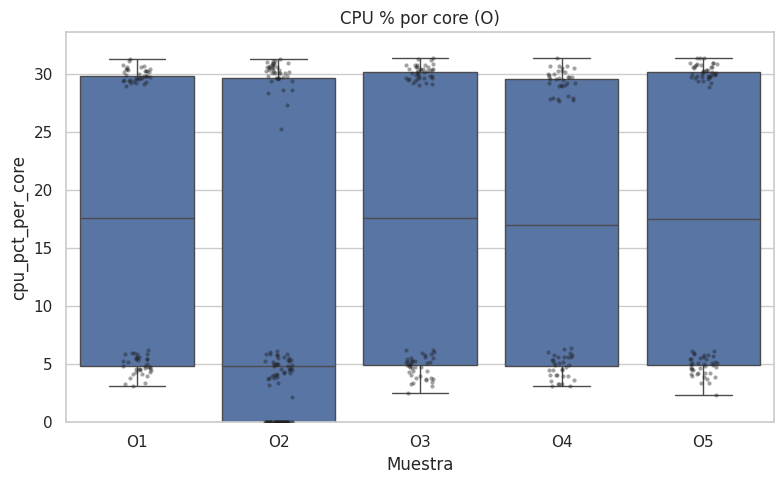

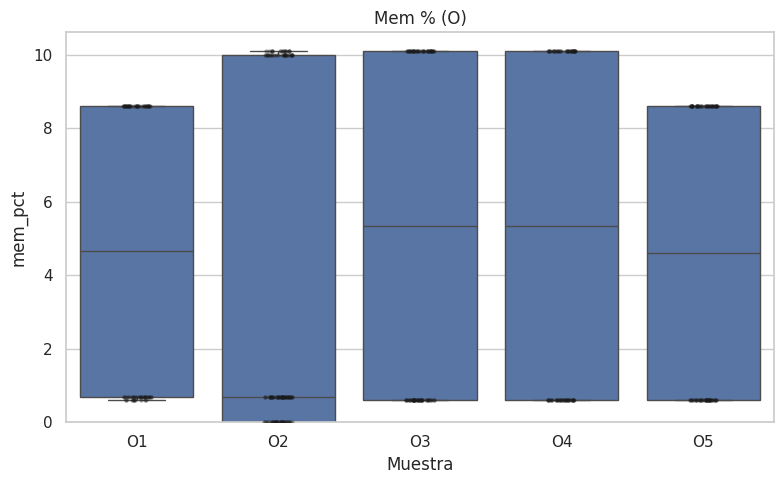

In [9]:
# Columnas y funciones de limpieza / análisis
COLUMNAS_RENDIMIENTO = [
    "snapshot_index",
    "timestamp",
    "source_file",
    "load1",
    "load5",
    "load15",
    "cpu_id",
    "cpu_pct",
    "mem_pct",
    "mem_used_mib",
    "pid",
    "user",
    "command",
]


def limpiar_dataframe(dataframe, muestra=None, columnas=None):
    """Devuelve una copia del DataFrame con solo las columnas útiles.

    Si `muestra` se indica, añade una columna adicional con ese identificador.
    """
    columnas = columnas or COLUMNAS_RENDIMIENTO
    columnas_disponibles = [c for c in columnas if c in dataframe.columns]
    limpio = dataframe.loc[:, columnas_disponibles].copy()
    if muestra is not None:
        limpio["muestra"] = muestra
    return limpio


def limpiar_dataframes(dataframes, columnas=None):
    """Limpia una secuencia de DataFrames usando `limpiar_dataframe`."""
    return tuple(
        limpiar_dataframe(df, muestra=i, columnas=columnas)
        for i, df in enumerate(dataframes, start=1)
    )


# Función de boxplot mejorada (gestiona outliers)
def boxplot_metricas(dataframes, columna, etiquetas=None, titulo=None, figsize=(8,5), clip_percentile=99, yscale='linear', showfliers=False, overlay_points=True, ylim=None):
    """Dibuja un boxplot para una columna concreta en varios DataFrames.

    Aplica recorte por percentil si `clip_percentile` no es None y, opcionalmente,
    superpone los puntos individuales para ver la dispersión real.
    """
    filas = []
    for i, df in enumerate(dataframes, start=1):
        if columna not in df.columns:
            continue
        m = df[[columna]].copy()
        m[columna] = pd.to_numeric(m[columna], errors='coerce')
        m = m.dropna(subset=[columna]).copy()
        if etiquetas and i - 1 < len(etiquetas):
            etiqueta = etiquetas[i - 1]
        else:
            etiqueta = f'muestra {i}'
        m['muestra'] = str(etiqueta)
        filas.append(m)
    if not filas:
        raise ValueError(f"Columna {columna} no encontrada en los dataframes")
    datos = pd.concat(filas, ignore_index=True)
    datos['muestra'] = datos['muestra'].astype(str)

    cutoff = None
    if clip_percentile is not None:
        try:
            cutoff = np.percentile(datos[columna].dropna(), clip_percentile)
            datos.loc[datos[columna] > cutoff, columna] = cutoff
        except Exception:
            cutoff = None

    plt.figure(figsize=figsize)
    ax = sns.boxplot(data=datos, x='muestra', y=columna, showfliers=showfliers)
    if overlay_points:
        if cutoff is not None:
            points = datos[datos[columna] <= cutoff]
        else:
            points = datos
        sns.stripplot(data=points, x='muestra', y=columna, color='k', size=3, alpha=0.4, jitter=True)

    ax.set_title(titulo or f'Boxplot de {columna}')
    ax.set_xlabel('Muestra')
    ax.set_ylabel(columna)
    if yscale == 'log':
        ax.set_yscale('log')
    if ylim is not None:
        try:
            ax.set_ylim(ylim)
        except Exception:
            pass
    plt.tight_layout()
    return ax


# Normalizar cpu_pct por número de cores
def add_cpu_per_core(dataframes):
    """Añade la columna `cpu_pct_per_core` normalizando `cpu_pct` por core lógico."""
    n_cores = os.cpu_count() or 1
    for df in dataframes:
        if 'cpu_pct' in df.columns and 'cpu_pct_per_core' not in df.columns:
            df['cpu_pct_per_core'] = pd.to_numeric(df['cpu_pct'], errors='coerce') / n_cores
    return dataframes


def resumen_cpu(dataframes, etiqueta_prefix='M'):
    """Calcula media, moda, mediana y rango global de CPU para las 5 muestras."""
    series = []
    for df in dataframes:
        col = 'cpu_pct_per_core' if 'cpu_pct_per_core' in df.columns else 'cpu_pct'
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if not s.empty:
            series.append(s)
    if not series:
        raise ValueError('No hay datos de CPU para resumir')
    valores = pd.concat(series, ignore_index=True)
    moda = valores.mode(dropna=True)
    moda_valor = moda.iloc[0] if not moda.empty else np.nan
    minimo = valores.min()
    maximo = valores.max()
    etiqueta = f'{etiqueta_prefix}1-{etiqueta_prefix}{len(dataframes)}'
    return pd.DataFrame([{'muestra': etiqueta, 'media': valores.mean(), 'moda': moda_valor, 'mediana': valores.median(), 'minimo': minimo, 'maximo': maximo, 'rango': f'{minimo:.4f} - {maximo:.4f}'}]).set_index('muestra')


def global_top_commands(dataframes, by='cpu_pct_per_core', top_n=3):
    """Obtiene los comandos con mayor consumo agregado entre varios DataFrames."""
    from collections import Counter
    counter = Counter()
    for df in dataframes:
        if by in df.columns:
            col = by
        elif 'cpu_pct' in df.columns:
            col = 'cpu_pct'
        else:
            continue
        grp = df.groupby('command')[col].mean().dropna()
        for cmd, val in grp.items():
            counter[cmd] += val
    return [cmd for cmd,_ in counter.most_common(top_n)]


def filter_by_commands(dataframes, commands):
    """Filtra cada DataFrame dejando solo las filas cuyos comandos estén en la lista."""
    if not commands:
        return dataframes
    return [df[df['command'].isin(commands)].copy() for df in dataframes]


# Pipeline compacto: carga -> limpia -> normaliza -> detecta top commands -> filtra -> resumen y plot

def run_pipeline(ruta, etiqueta_prefix='M', commands=None, cpu_ylim=None, mem_ylim=None):
    """Procesa una carpeta de CSVs y devuelve los DataFrames filtrados.

    Si `commands` es None, calcula automáticamente los comandos más relevantes
    a partir de los datos leídos.
    """
    usecols = COLUMNAS_RENDIMIENTO
    dfs = tomar_dataframes(ruta, usecols=usecols)
    limp = limpiar_dataframes(dfs, columnas=COLUMNAS_RENDIMIENTO)
    limp = add_cpu_per_core(limp)

    if commands is None:
        top_cmds = global_top_commands(limp, top_n=3)
    else:
        top_cmds = commands

    print(f'Top commands for {etiqueta_prefix}:', top_cmds)
    filtrados = filter_by_commands(limp, top_cmds)
    display(resumen_cpu(filtrados, etiqueta_prefix))
    # CPU plot
    if any('cpu_pct_per_core' in df.columns for df in filtrados):
        boxplot_metricas(filtrados, 'cpu_pct_per_core', etiquetas=[f'{etiqueta_prefix}{i}' for i in range(1, len(filtrados)+1)], titulo=f'CPU % por core ({etiqueta_prefix})', clip_percentile=99, ylim=cpu_ylim)
    else:
        boxplot_metricas(filtrados, 'cpu_pct', etiquetas=[f'{etiqueta_prefix}{i}' for i in range(1, len(filtrados)+1)], titulo=f'CPU % ({etiqueta_prefix})', clip_percentile=99, ylim=cpu_ylim)
    # Mem plot
    if any('mem_pct' in df.columns for df in filtrados):
        boxplot_metricas(filtrados, 'mem_pct', etiquetas=[f'{etiqueta_prefix}{i}' for i in range(1, len(filtrados)+1)], titulo=f'Mem % ({etiqueta_prefix})', clip_percentile=99, ylim=mem_ylim)

    return filtrados


# Ejecutar ambos pipelines usando los mismos "top commands" combinados entre Gazebo y O3DE
usecols = COLUMNAS_RENDIMIENTO
gazebo_filtrados = None
o3de_filtrados = None

gazebo_exists = Path(ruta_gazebo).exists()
o3de_exists = Path(ruta_o3de).exists()

if not gazebo_exists and not o3de_exists:
    print('No se encontraron las carpetas Gazebo ni O3DE')
else:
    # Leer y preparar ambos conjuntos (si existen) para calcular top commands combinados
    combined_for_top = []
    if gazebo_exists:
        tmp_g = limpiar_dataframes(tomar_dataframes(ruta_gazebo, usecols=usecols), columnas=usecols)
        tmp_g = add_cpu_per_core(tmp_g)
        combined_for_top.extend(tmp_g)
    if o3de_exists:
        tmp_o = limpiar_dataframes(tomar_dataframes(ruta_o3de, usecols=usecols), columnas=usecols)
        tmp_o = add_cpu_per_core(tmp_o)
        combined_for_top.extend(tmp_o)

    # Calcular top commands conjuntos
    if combined_for_top:
        common_top_cmds = global_top_commands(combined_for_top, top_n=3)
    else:
        common_top_cmds = []

    # Calcular límites comunes (cpu y mem) antes de plotear
    def _cpu_col_for_df(df):
        """Devuelve la columna de CPU disponible para una muestra concreta."""
        if 'cpu_pct_per_core' in df.columns:
            return 'cpu_pct_per_core'
        if 'cpu_pct' in df.columns:
            return 'cpu_pct'
        return None

    cpu_max = 0
    mem_max = 0
    for df in combined_for_top:
        ccol = _cpu_col_for_df(df)
        if ccol is not None:
            vals = pd.to_numeric(df[ccol], errors='coerce').dropna()
            if len(vals):
                cpu_max = max(cpu_max, vals.max())
        if 'mem_pct' in df.columns:
            mvals = pd.to_numeric(df['mem_pct'], errors='coerce').dropna()
            if len(mvals):
                mem_max = max(mem_max, mvals.max())

    def margin(x):
        """Añade un pequeño margen superior a un máximo para usarlo como límite de eje."""
        return x * 1.05 if x>0 else 1

    cpu_ylim = (0, margin(cpu_max)) if cpu_max>0 else None
    mem_ylim = (0, margin(mem_max)) if mem_max>0 else None

    print('\nTop commands combinados:', common_top_cmds)
    print('cpu_ylim=', cpu_ylim, 'mem_ylim=', mem_ylim)

    # Ahora ejecutar cada pipeline especificando los mismos commands y los límites comunes
    if gazebo_exists:
        print('\n=== Gazebo ===')
        gazebo_filtrados = run_pipeline(ruta_gazebo, 'G', commands=common_top_cmds, cpu_ylim=cpu_ylim, mem_ylim=mem_ylim)
    else:
        print('No se encontró la carpeta Gazebo')

    if o3de_exists:
        print('\n=== O3DE ===')
        o3de_filtrados = run_pipeline(ruta_o3de, 'O', commands=common_top_cmds, cpu_ylim=cpu_ylim, mem_ylim=mem_ylim)
    else:
        print('No se encontró la carpeta O3DE')
